### Imports

In [1]:
import os
from utils import *
import seaborn as sns
from modules import *
import utils.for_climate as climate
import utils.for_empatica as empatica
import pluma.schema.outdoor as outdoor
from systole.detection import ecg_peaks

Current city is copenhagen!
If you wish to change the city, please edit the value in the __init__.py file


/home/s243636/miniforge3/envs/tese/lib/python3.9/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
# where getting raw and processed data from
rawdata = "/mnt/raid/emotional_data_raquel"

__________

# Participant level

In [3]:
base_dir = os.path.join(rawdata, "fulldata_mine")

good_participants = set()
bad_participants = set()

for sub in os.listdir(base_dir):
    sub_path = os.path.join(base_dir, sub)
    if not os.path.isdir(sub_path):
        continue

    participant_is_bad = False  # track per participant

    for ses in os.listdir(sub_path):
        ses_path = os.path.join(sub_path, ses)
        file_path = os.path.join(ses_path, "alldata.csv")

        if not os.path.exists(file_path):
            print(f"❌ MISSING FILE: {sub} - {ses}")
            participant_is_bad = True
            continue

        try:
            df = pd.read_csv(file_path)

            if df.empty:
                print(f"⚠️ EMPTY FILE:  {sub} - {ses}")
                participant_is_bad = True
            else:
                print(f"✅ OK:          {sub} - {ses} ({len(df)} rows)")

        except Exception as e:
            print(f"🔥 CORRUPT FILE: {sub} - {ses} | Error: {e}")
            participant_is_bad = True

    # after checking all sessions for this participant
    if participant_is_bad:
        bad_participants.add(sub)
    else:
        good_participants.add(sub)

✅ OK:          sub-OE020 - ses-Norrebro (1587 rows)
✅ OK:          sub-OE020 - ses-Nordhavn (1502 rows)
✅ OK:          sub-OE005 - ses-Nordhavn (1383 rows)
✅ OK:          sub-OE005 - ses-Hellerup (1499 rows)
✅ OK:          sub-OE018 - ses-Hellerup (1602 rows)
⚠️ EMPTY FILE:  sub-OE012 - ses-Norreport
✅ OK:          sub-OE021 - ses-Norrebro (1263 rows)
✅ OK:          sub-OE021 - ses-Hellerup (1601 rows)
✅ OK:          sub-OE015 - ses-Norreport (1465 rows)
✅ OK:          sub-OE002 - ses-Hellerup (1473 rows)
✅ OK:          sub-OE022 - ses-Norrebro (1484 rows)
✅ OK:          sub-OE022 - ses-Norreport (1545 rows)
✅ OK:          sub-OE022 - ses-Nordhavn (1432 rows)
✅ OK:          sub-OE009 - ses-Norrebro (1374 rows)
✅ OK:          sub-OE009 - ses-Nordhavn (1670 rows)
⚠️ EMPTY FILE:  sub-OE007 - ses-Hellerup
✅ OK:          sub-OE019 - ses-Hellerup (1796 rows)
⚠️ EMPTY FILE:  sub-OE017 - ses-Norreport
✅ OK:          sub-OE023 - ses-Norrebro (1520 rows)
✅ OK:          sub-OE023 - ses-Norreport 

_________

## Bad participant reasoning

Meaning, why is there 3 participants that present empty files?

In [4]:
results = []

for sub in bad_participants:
    sub_path = os.path.join(rawdata, "data", sub.replace("sub-", ""))

    if not os.path.exists(sub_path):
        print(f"❌ Missing participant folder: {sub}")
        continue

    for session_folder in os.listdir(sub_path):
        session_path = os.path.join(sub_path, session_folder)

        if not os.path.isdir(session_path):
            continue

        session_name = extract_session_name(session_folder)

        # ---- define paths ----
        empatica_data_path = os.path.join(
            rawdata, 'supp_mine', 'stress_csv', sub, f'ses-{session_name}', '_1hz', 'data_all_1Hz.csv'
        )

        geodata_data_path = os.path.join(
            rawdata, 'supp', 'geodata', 'log', sub, f'ses-{session_name}',
            f'{sub}_ses-{session_name}_geodata.xlsx'
        )

        gaze_data_path = os.path.join(
            rawdata, 'supp_mine', 'gaze', sub, f'ses-{session_name}', 'gaze.csv'
        )

        eeg_data_path = os.path.join(
            rawdata,
            'analysis-climate_physio_eeg_model_pipeline-outdoor_literature',
            sub, f'ses-{session_name}',
            'data', 'a01_psd_compute.m', 'eeg_power.xlsx'
        )

        # ---- check existence ----
        results.append({
            "participant": sub,
            "session": session_name,
            "empatica": os.path.exists(empatica_data_path),
            "geodata": os.path.exists(geodata_data_path),
            "gaze": os.path.exists(gaze_data_path),
            "eeg": os.path.exists(eeg_data_path),
        })

df_check = pd.DataFrame(results)

In [5]:
df_check

,participant,session,empatica,geodata,gaze,eeg
0,sub-OE017,Norreport,False,False,True,False
1,sub-OE007,Hellerup,False,False,True,False
2,sub-OE012,Norreport,False,False,True,False


Missing core streams (geodata + empatica + eeg)
➜ leads to empty merged dataset </p>

The current pipeline is:</p>

GEODATA → base timeline</p>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓</p>
EMPATICA → merged</p>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓</p>
GAZE → merged</p>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓</p>
EEG → merged</p>

Therefore, without geodata, NOTHING works

_______________

## Good participants

In [6]:
def check_streams(df):
    return {
        "gps": df["original_latitude"].notna().any() if "original_latitude" in df else False,

        "empatica_hr": df["E4_HR"].notna().any() if "E4_HR" in df else False,

        "ecg_hr": df["ECG_HR"].notna().any() if "ECG_HR" in df else False,

        "eda": df["eda_raw"].notna().any() if "eda_raw" in df else False,

        "gaze": (
            df["GazeX"].notna().any() and df["GazeY"].notna().any()
            if "GazeX" in df and "GazeY" in df else False
        ),

        "eeg": (
            df["alpha"].notna().any()
            if "alpha" in df else False
        ),

        "climate": df["temp_atmospheric"].notna().any() if "temp_atmospheric" in df else False,

        "noise": df["noise_level"].notna().any() if "noise_level" in df else False,
    }

In [7]:
results = []

for sub in good_participants:
    sub_path = os.path.join(base_dir, sub)

    for ses in os.listdir(sub_path):
        file_path = os.path.join(sub_path, ses, "alldata.csv")

        df = pd.read_csv(file_path)

        streams = check_streams(df)

        results.append({
            "participant": sub,
            "session": ses,
            **streams
        })

df_streams = pd.DataFrame(results)

In [8]:
df_streams

,participant,session,gps,empatica_hr,ecg_hr,eda,gaze,eeg,climate,noise
0,sub-OE010,ses-Nordhavn,True,True,True,True,True,False,True,True
1,sub-OE023,ses-Norrebro,True,True,True,True,True,True,True,True
2,sub-OE023,ses-Norreport,True,True,True,True,True,True,True,True
3,sub-OE023,ses-Nordhavn,True,True,True,True,True,False,True,True
4,sub-OE020,ses-Norrebro,True,True,True,True,True,True,True,True
5,sub-OE020,ses-Nordhavn,True,True,True,True,True,True,True,True
6,sub-OE022,ses-Norrebro,True,True,True,True,True,True,True,True
7,sub-OE022,ses-Norreport,True,True,True,True,True,True,True,True
8,sub-OE022,ses-Nordhavn,True,True,True,True,True,True,True,True
9,sub-OE021,ses-Norrebro,True,True,True,True,True,True,True,True


In [9]:
df_streams[
    (df_streams["empatica_hr"] == False) |
    (df_streams["gaze"] == False) |
    (df_streams["eeg"] == False)
]

,participant,session,gps,empatica_hr,ecg_hr,eda,gaze,eeg,climate,noise
0,sub-OE010,ses-Nordhavn,True,True,True,True,True,False,True,True
3,sub-OE023,ses-Nordhavn,True,True,True,True,True,False,True,True
11,sub-OE024,ses-Nordhavn,True,True,True,True,True,False,True,True
12,sub-OE015,ses-Norreport,True,False,True,False,True,False,True,True
18,sub-OE019,ses-Hellerup,True,False,True,False,True,False,True,True


### What is wrong with HR measures (from Empatica)?

In [10]:
keywords = ["hr", "heart", "bpm", "ibi", "pulse"]
cols = [col for col in df.columns if any(k in col.lower() for k in keywords)]
print(cols)

['E4_HR', 'empatica_heart_rate', 'HR', 'empatica_e4_hr', 'empatica_e4_ibi', 'ECG_HR', 'ECG_HR_smooth']


In [11]:
base_path = "/mnt/raid/emotional_data_raquel/fulldata_mine"

results = []

for sub in os.listdir(base_path):

    sub_path = os.path.join(base_path, sub)
    if not os.path.isdir(sub_path):
        continue

    for ses in os.listdir(sub_path):

        ses_path = os.path.join(sub_path, ses)
        if not os.path.isdir(ses_path):
            continue

        file_path = os.path.join(ses_path, "alldata.csv")  # adjust if needed

        if not os.path.exists(file_path):
            continue

        try:
            df = pd.read_csv(file_path)

            # ensure columns exist
            if "E4_HR" not in df.columns or "HR" not in df.columns:
                continue

            # convert to numeric (important!)
            df["E4_HR"] = pd.to_numeric(df["E4_HR"], errors="coerce")
            df["HR"] = pd.to_numeric(df["HR"], errors="coerce")

            # compute missing %
            e4_missing = df["E4_HR"].isna().mean() * 100
            hr_missing = df["HR"].isna().mean() * 100

            results.append({
                "participant": sub,
                "session": ses,
                "E4_HR_missing_%": e4_missing,
                "HR_missing_%": hr_missing
            })

        except Exception as e:
            print(f"Error in {sub}/{ses}: {e}")

# convert to dataframe
results_df = pd.DataFrame(results)

# show
print(results_df)

# summary
print("\n=== SUMMARY ===")
print(results_df.describe())

   participant        session  E4_HR_missing_%  HR_missing_%
0    sub-OE020   ses-Norrebro        99.117832      8.947700
1    sub-OE020   ses-Nordhavn        90.612517     15.046605
2    sub-OE005   ses-Nordhavn        99.421547     28.778019
3    sub-OE005   ses-Hellerup        90.460307     28.285524
4    sub-OE018   ses-Hellerup        94.382022     26.716604
5    sub-OE021   ses-Norrebro        34.045922     45.447348
6    sub-OE021   ses-Hellerup        99.063086      4.559650
7    sub-OE002   ses-Hellerup        99.592668     42.905635
8    sub-OE022   ses-Norrebro        73.989218     19.272237
9    sub-OE022  ses-Norreport        82.588997     22.847896
10   sub-OE022   ses-Nordhavn        89.036313     13.058659
11   sub-OE009   ses-Norrebro        89.592431      2.110626
12   sub-OE009   ses-Nordhavn        73.053892     54.790419
13   sub-OE023   ses-Norrebro        53.881579     10.592105
14   sub-OE023  ses-Norreport        70.189702     17.750678
15   sub-OE023   ses-Nor

In [12]:
df[cols].describe()

,E4_HR,empatica_heart_rate,HR,empatica_e4_hr,empatica_e4_ibi,ECG_HR,ECG_HR_smooth
count,9.000000,9.000000,1201.000000,9.000000,9.000000,1420.000000,1420.000000
mean,120.675828,0.512176,101.390255,120.675828,0.512176,95.573507,95.822393
std,22.813125,0.082601,24.883417,22.813125,0.082601,12.600218,8.967657
min,91.424350,0.343766,73.170732,91.424350,0.343766,46.691735,74.661128
25%,109.709200,0.484398,88.235294,109.709200,0.484398,86.975802,90.027850
50%,116.358300,0.515649,95.454545,116.358300,0.515649,95.363942,96.642784
75%,123.865200,0.546900,100.446429,123.865200,0.546900,101.929843,101.166786
max,174.537300,0.656280,200.000000,174.537300,0.656280,150.000000,132.022451


_E4_HR_ and _empatica_e4_hr_ are the same </p>
_empatica_heart_rate_ and _empatica_e4_ibi_ are the same also </p>
_HR_ could be coming from the ECG device (because it has around 28% of missing values isntead of the 90% of the rest), however its values (mean ≈ 163 bpm & max = 200 bpm) are a bit suspicius

In [13]:
df[cols].isna().mean()

E4_HR                  0.993827
empatica_heart_rate    0.993827
HR                     0.176269
empatica_e4_hr         0.993827
empatica_e4_ibi        0.993827
ECG_HR                 0.026063
ECG_HR_smooth          0.026063
dtype: float64

Turns out _HR_ is the ECG variable since this is what happens in for_empatica:

In [14]:
# data_all = pd.merge(data_all, data_hrlead[['DateTime', 'Bpm']].rename(columns={'Bpm': 'HR'}), on='DateTime', how='outer')

#### Raw ECG data

In [15]:
participant_path = "/mnt/raid/emotional_data_raquel/data/OE002"
session_folder = os.listdir(participant_path)[0]
session_path = os.path.join(participant_path, session_folder)

datapicker = create_datapicker(path=session_path, schema=build_schema)
dataset = load_dataset(datapicker.selected_path, schema=build_schema)

print(dataset.streams.BioData.ECG.data.keys())

Attempting to automatically correct eeg timestamps to harp timestamps...
Done.
odict_keys(['Raw', 'Filtered', 'Processed', 'HeartRate'])


### Check existing HR values from ECG device

In [16]:
base_path = "/mnt/raid/emotional_data_raquel/supp_mine/stress_csv"

for sub in os.listdir(base_path):

    sub_path = os.path.join(base_path, sub)
    if not os.path.isdir(sub_path):
        continue

    print(f"\n===== {sub} =====")

    for ses in os.listdir(sub_path):

        ses_path = os.path.join(sub_path, ses)
        if not os.path.isdir(ses_path):
            continue

        hr_file = os.path.join(ses_path, "ecg_hr.csv")

        print(f"\n--- {ses} ---")

        if not os.path.exists(hr_file):
            print("❌ No ecg_hr.csv — skipping")
            continue

        try:
            # load HR
            df = pd.read_csv(hr_file)

            # try to parse time
            if "Seconds" in df.columns:
                df["Seconds"] = pd.to_datetime(df["Seconds"])
                df = df.set_index("Seconds")

            # get HR column (sometimes named differently)
            hr_col = df.columns[-1]  # usually last column
            hr = df[hr_col]

            # info
            print(f"Time range: {hr.index.min()} → {hr.index.max()}")
            print(f"Samples: {len(hr)}")

            print("\nDescribe:")
            desc = hr.describe()
            print(desc)

            if desc["50%"] > 150:  # median too high
                print("❌ BAD SESSION — skipping")
                continue

        except Exception as e:
            print(f"⚠️ Error: {e}")
            continue


===== sub-OE020 =====

--- ses-Norrebro ---
Time range: 2024-06-24 08:45:07.503525478 → 2024-06-24 09:11:49.623525478
Samples: 2187

Describe:
count    2187.000000
mean       97.849519
std        20.085065
min        69.767442
25%        88.235294
50%        93.750000
75%        96.774194
max       200.000000
Name: Bpm, dtype: float64

--- ses-Nordhavn ---
Time range: 2024-06-25 14:56:38.087044186 → 2024-06-25 15:21:54.287044186
Samples: 1770

Describe:
count    1770.000000
mean       93.660128
std        22.619950
min        68.181818
25%        83.333333
50%        88.235294
75%        93.750000
max       200.000000
Name: Bpm, dtype: float64

===== sub-OE005 =====

--- ses-Nordhavn ---
Time range: 2024-06-28 11:28:26.818592119 → 2024-06-28 11:51:44.978592119
Samples: 1491

Describe:
count    1491.000000
mean      105.393497
std        22.731184
min        71.428571
25%        93.750000
50%       103.448276
75%       107.142857
max       200.000000
Name: Bpm, dtype: float64

--- ses-

In [17]:
hr = "/mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE005/ses-Hellerup/ecg_hr.csv"
hr = pd.read_csv(hr)
print(hr.head())
print(hr.describe())

                         Seconds         Bpm
0  2024-06-27 11:35:22.629018214  200.000000
1  2024-06-27 11:35:23.209018214  103.448276
2  2024-06-27 11:35:23.349018214  200.000000
3  2024-06-27 11:36:00.809018214  200.000000
4  2024-06-27 11:36:02.189018214  200.000000
               Bpm
count  3142.000000
mean    170.748471
std      40.169396
min      93.750000
25%     130.434783
50%     200.000000
75%     200.000000
max     200.000000


## Add ECG raw to collected files

In [18]:
base_path = "/mnt/raid/emotional_data_raquel/data"
output_base = "/mnt/raid/emotional_data_raquel/supp_mine/stress_csv"

for participant in os.listdir(base_path):

    participant_path = os.path.join(base_path, participant)

    if not os.path.isdir(participant_path):
        continue

    # define participant name
    sub_name = f"sub-{participant}" if not participant.startswith("sub-") else participant

    print(f"\n===== {sub_name} =====")

    for session in os.listdir(participant_path):

        session_path = os.path.join(participant_path, session)

        if not os.path.isdir(session_path):
            continue

        # CLEAN session name using your function
        session_clean = extract_session_name(session)
        ses_name = f"ses-{session_clean}"

        print(f"--- {ses_name} ---")

        try:
            # Load dataset
            datapicker = create_datapicker(path=session_path, schema=build_schema)
            dataset = load_dataset(datapicker.selected_path, schema=build_schema)

            ecg_keys = dataset.streams.BioData.ECG.data.keys()

            if "Raw" not in ecg_keys:
                print("❌ No ECG Raw — skipping")
                continue

            ecg_raw = dataset.streams.BioData.ECG.data.Raw
            ecg_raw = ecg_raw["Value0"]
            ecg_raw = ecg_raw.rename("Value")

            # Create output path
            outdir = os.path.join(output_base, sub_name, ses_name)
            os.makedirs(outdir, exist_ok=True)

            # Save ECG raw
            ecg_raw.to_csv(os.path.join(outdir, "ecg_raw.csv"), index=True)

            print(f"Saved to {outdir}")

        except Exception as e:
            print(f"⚠️ Error in {sub_name} / {ses_name}: {e}")
            continue


===== sub-OE011 =====
--- ses-Nordhavn ---
Attempting to automatically correct eeg timestamps to harp timestamps...
Done.
Saved to /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE011/ses-Nordhavn

===== sub-OE015 =====
--- ses-Norreport ---
Saved to /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE015/ses-Norreport

===== sub-OE019 =====
--- ses-Hellerup ---
Attempting to automatically correct eeg timestamps to harp timestamps...
Done.
Saved to /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE019/ses-Hellerup

===== sub-OE010 =====
--- ses-Nordhavn ---
Attempting to automatically correct eeg timestamps to harp timestamps...
Done.
Saved to /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE010/ses-Nordhavn

===== sub-OE024 =====
--- ses-Nordhavn ---
Attempting to automatically correct eeg timestamps to harp timestamps...
Done.
Saved to /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE024/ses-Nordhavn

===== sub-OE018 =====
--- ses-Heller

## Process ECG HR

### Participant level

In [19]:
df = pd.read_csv("/mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE002/ses-Hellerup/ecg_raw.csv", parse_dates=["Seconds"])
df = df.set_index("Seconds")
ecg_signal = df["Value"].values
sfreq = 1000 # sampling rate is ~1000 Hz

In [20]:
signal, peaks = ecg_peaks(ecg_signal, method='pan-tompkins', sfreq=sfreq)
peaks

array([False, False, False, ..., False, False, False])

False → no peak  </p>
True  → this sample is a peak (heartbeat)

In [21]:
t = (df.index - df.index[0]).total_seconds()
tpeaks = t[peaks]
RR = np.diff(tpeaks)

# keep only heartbeats that are physiologically possible
# RR = 0.4 s → HR = 150 bpm
# RR = 1.5 s → HR = 40 bpm
valid = (RR > 0.4) & (RR < 1.5)

RR = RR[valid]
t_hr = tpeaks[1:][valid]

HR = 60 / RR

In [22]:
%matplotlib inline

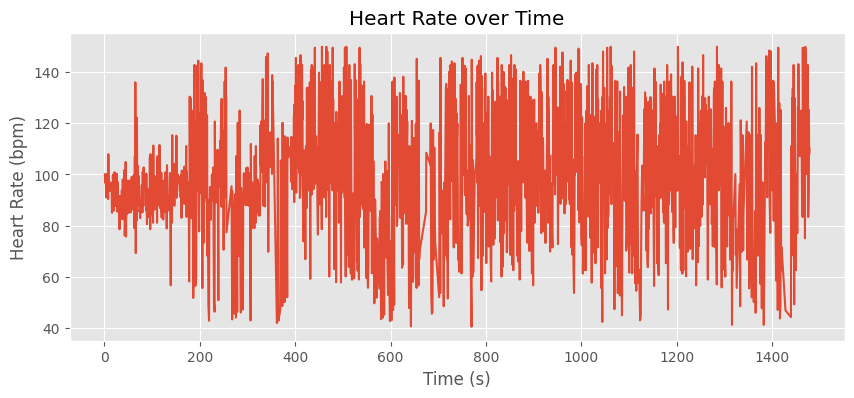

In [23]:
plt.figure(figsize=(10,4))
plt.plot(t_hr, HR)
plt.xlabel("Time (s)")
plt.ylabel("Heart Rate (bpm)")
plt.title("Heart Rate over Time")
plt.show()

In [24]:
HR_smooth = pd.Series(HR).rolling(5, center=True).mean()

#### Sliding window intuition (rolling 5)

Original:   80   82   150   79   81   83   85   84   86   87</p>
Smoothed:  NaN  NaN   94    94    95    82    84    85   NaN  NaN

HR:     ──●──●──●──●──●──●──●──●──●──●── </p>

Window:      [===========]</p>
Shift:         [===========]</p>
Shift again:     [===========]</p>

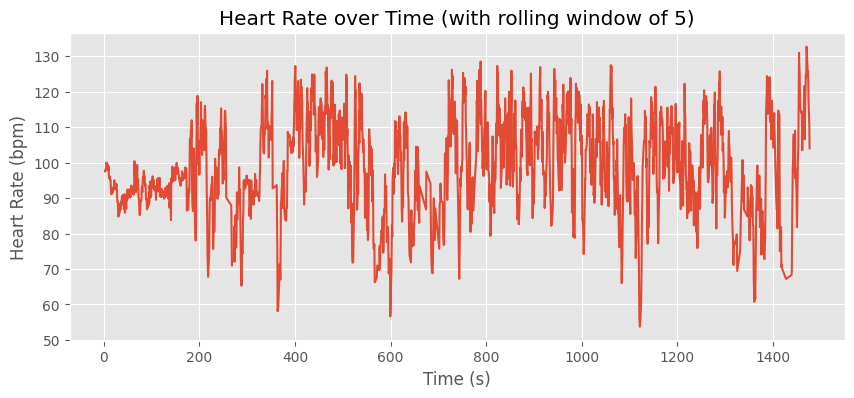

In [25]:
plt.figure(figsize=(10,4))
plt.plot(t_hr, HR_smooth)
plt.xlabel("Time (s)")
plt.ylabel("Heart Rate (bpm)")
plt.title("Heart Rate over Time (with rolling window of 5)")
plt.show()

## Process ECG HR with Systole

In [26]:
root = "/mnt/raid/emotional_data_raquel/supp_mine/stress_csv"

for participant in os.listdir(root):
    participant_path = os.path.join(root, participant)

    if not os.path.isdir(participant_path):
        continue

    for session in os.listdir(participant_path):
        session_path = os.path.join(participant_path, session)
        # Path to ECG raw data file
        ecg_path = os.path.join(session_path, "ecg_raw.csv")

        if not os.path.exists(ecg_path):
            continue

        print(f"Processing {participant} / {session}")

        try:
            # -----------------------------
            # LOAD
            # -----------------------------
            df = pd.read_csv(ecg_path, parse_dates=["Seconds"])
            df = df.set_index("Seconds")

            # Extract ECG signal as array
            ecg_signal = df["Value"].values
            sfreq = 1000 # sampling rate is ~1000 Hz

            # -----------------------------
            # R-PEAK DETECTION (heartbeat events)
            # -----------------------------
            signal, peaks = ecg_peaks(ecg_signal, method='pan-tompkins', sfreq=sfreq)

            # -----------------------------
            # TIME
            # -----------------------------
            # Convert timestamps to seconds relative to start
            t = (df.index - df.index[0]).total_seconds()
            tpeaks = t[peaks] # time of detected peak

            # -----------------------------
            # RR + HR
            # -----------------------------
            # Compute RR intervals (time between beats)
            RR = np.diff(tpeaks)

            # keep only heartbeats that are physiologically possible
            # RR = 0.4 s → HR = 150 bpm
            # RR = 1.5 s → HR = 40 bpm
            valid = (RR > 0.4) & (RR < 1.5)
            RR = RR[valid]
            # Align time with valid RR intervals
            t_hr = tpeaks[1:][valid]
            # Convert RR to heart rate (bpm)
            HR = 60 / RR

            # -----------------------------
            # SMOOTH
            # -----------------------------
            # Smooth HR using moving average
            HR_smooth = pd.Series(HR).rolling(5, center=True).mean()

            # Get normal timing back
            timestamps = df.index[peaks][1:][valid]

            # -----------------------------
            # SAVE
            # -----------------------------
            out_df = pd.DataFrame({
                "timestamp": timestamps,
                "time_sec": t_hr,
                "ECG_HR": HR,
                "ECG_HR_smooth": HR_smooth
            })

            save_path = os.path.join(session_path, "ecg_final_hr.csv")
            out_df.to_csv(save_path, index=False)

            print(f"Saved → {save_path}")

        except Exception as e:
            print(f"Error in {participant}/{session}: {e}")

Processing sub-OE020 / ses-Norrebro
Saved → /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE020/ses-Norrebro/ecg_final_hr.csv
Processing sub-OE020 / ses-Nordhavn
Saved → /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE020/ses-Nordhavn/ecg_final_hr.csv
Processing sub-OE005 / ses-Nordhavn
Saved → /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE005/ses-Nordhavn/ecg_final_hr.csv
Processing sub-OE005 / ses-Hellerup
Saved → /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE005/ses-Hellerup/ecg_final_hr.csv
Processing sub-OE018 / ses-Hellerup
Saved → /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE018/ses-Hellerup/ecg_final_hr.csv
Processing sub-OE012 / ses-Norreport
Saved → /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE012/ses-Norreport/ecg_final_hr.csv
Processing sub-OE021 / ses-Norrebro
Saved → /mnt/raid/emotional_data_raquel/supp_mine/stress_csv/sub-OE021/ses-Norrebro/ecg_final_hr.csv
Processing sub-OE021 / ses-Hellerup
Sav

## Add final ECG HR varible to all_data files

In [27]:
root_ecg_hr = "/mnt/raid/emotional_data_raquel/supp_mine/stress_csv"
root_all = "/mnt/raid/emotional_data_raquel/fulldata_mine"

for participant in os.listdir(root_ecg_hr):
    for session in os.listdir(os.path.join(root_ecg_hr, participant)):

        session_hr_path = os.path.join(root_ecg_hr, participant, session, "ecg_final_hr.csv")
        session_all_path = os.path.join(root_all, participant, session, "alldata.csv")

        if not os.path.exists(session_hr_path) or not os.path.exists(session_all_path):
            continue

        print(f"Merging {participant} / {session}")

        try:
            # -----------------------------
            # LOAD
            # -----------------------------
            df_hr = pd.read_csv(session_hr_path, parse_dates=["timestamp"])
            df_all = pd.read_csv(session_all_path, parse_dates=["time"])

            # -----------------------------
            # REMOVE OLD ECG COLUMNS (CRITICAL)
            # -----------------------------
            cols_to_remove = [col for col in df_all.columns if "ECG_HR" in col]
            df_all = df_all.drop(columns=cols_to_remove, errors="ignore")

            # -----------------------------
            # RESAMPLE ECG → 1 Hz
            # -----------------------------
            df_hr = df_hr.set_index("timestamp")
            # Take the mean value out of all values within one second
            df_hr_1hz = df_hr.resample("1S").mean().reset_index()

            # -----------------------------
            # MERGE
            # -----------------------------
            df_merged = df_all.merge(
                df_hr_1hz,
                left_on="time",
                right_on="timestamp",
                how="left"
            )
            
            df_merged = df_merged.drop(columns=["timestamp", "time_sec"], errors="ignore")

            # -----------------------------
            # SAVE
            # -----------------------------
            df_merged.to_csv(session_all_path, index=False)

            print("Saved")

        except Exception as e:
            print(f"Error in {participant}/{session}: {e}")

Merging sub-OE020 / ses-Norrebro
Saved
Merging sub-OE020 / ses-Nordhavn
Saved
Merging sub-OE005 / ses-Nordhavn
Saved
Merging sub-OE005 / ses-Hellerup
Saved
Merging sub-OE018 / ses-Hellerup
Saved
Merging sub-OE012 / ses-Norreport
Saved
Merging sub-OE021 / ses-Norrebro
Saved
Merging sub-OE021 / ses-Hellerup
Saved
Merging sub-OE015 / ses-Norreport
Saved
Merging sub-OE002 / ses-Hellerup
Saved
Merging sub-OE022 / ses-Norrebro
Saved
Merging sub-OE022 / ses-Norreport
Saved
Merging sub-OE022 / ses-Nordhavn
Saved
Merging sub-OE009 / ses-Norrebro
Saved
Merging sub-OE009 / ses-Nordhavn
Saved
Merging sub-OE007 / ses-Hellerup
Saved
Merging sub-OE019 / ses-Hellerup
Saved
Merging sub-OE017 / ses-Norreport
Saved
Merging sub-OE023 / ses-Norrebro
Saved
Merging sub-OE023 / ses-Norreport
Saved
Merging sub-OE023 / ses-Nordhavn
Saved
Merging sub-OE011 / ses-Nordhavn
Saved
Merging sub-OE004 / ses-Norreport
Saved
Merging sub-OE010 / ses-Nordhavn
Saved
Merging sub-OE024 / ses-Nordhavn
Saved


# Participant Summary



Missing core streams (geodata + empatica + eeg)
➜ leads to empty merged dataset

---

Total sessions: **25** </p>
Valid sessions: **22**</p>
⚠️ Empty sessions: **3**

---

HR data quality:

E4_HR (Empatica) → ~85% missing ❌</p>
Device HR → ~19% missing ⚠️</p>

➜ Empatica HR largely unusable

---

Created new variables:
ECG_HR</p>
ECG_HR_smooth</p>

➜ derived from ECG (peak detection + filtering + smoothing)</p>
➜ lower missingness + more stable

---

Therefore:

ECG_HR → primary physiological signal

---

Final usable data:

ECG_HR + geodata + environment + gaze

---

Limitations:

* missing EEG</p>
* high Empatica missingness</p>
* uneven multimodal coverage

---

Key insight:

ECG processing made physiological analysis possible


_____
___________

# Variable categories level

In [28]:
groups = {
    "gps": ["gps"],
    "empatica": ["empatica_hr", "eda"],
    "eeg": ["eeg"],
    "ecg_hr": ["ecg_hr"],
    "gaze": ["gaze"],
    "climate": ["climate"],
    "noise": ["noise"]
}

group_variables = {
    "empatica": ["E4_HR", "empatica_heart_rate", "empatica_e4_hr", "HR","eda_raw", "eda_phasic","bvp", 
                 "empatica_e4_ibi","empatica_e4_temperature","skin_temperature"],

    "ecg_hr": ["ECG_HR", "ECG_HR_smooth"],
    
    "eeg": ["delta","theta","alpha","beta","gamma","frontal alpha","frontal midline theta","theta-beta ratio","frontal alpha asymmetry","frontal theta"],
    
    "gaze": ["GazeX", "GazeY"],
    
    "gps": ["original_longitude", "original_latitude", "latitude_corrected", "longitude_corrected", "cum_dist"],
    
    "climate": ["atmospheric_temperature", "humidity", "wind_speed", "mrt", "air_temperature",
                "pm1_0", "pm2_5", "pm10_0"],

    "noise": ["noise_level", "sound_pressure_level"]
}

In [29]:
valid_groups = {}

for name, cols in groups.items():
    valid_groups[name] = df_streams[df_streams[cols].all(axis=1)]

valid_groups["eeg"]

,participant,session,gps,empatica_hr,ecg_hr,eda,gaze,eeg,climate,noise
1,sub-OE023,ses-Norrebro,True,True,True,True,True,True,True,True
2,sub-OE023,ses-Norreport,True,True,True,True,True,True,True,True
4,sub-OE020,ses-Norrebro,True,True,True,True,True,True,True,True
5,sub-OE020,ses-Nordhavn,True,True,True,True,True,True,True,True
6,sub-OE022,ses-Norrebro,True,True,True,True,True,True,True,True
7,sub-OE022,ses-Norreport,True,True,True,True,True,True,True,True
8,sub-OE022,ses-Nordhavn,True,True,True,True,True,True,True,True
9,sub-OE021,ses-Norrebro,True,True,True,True,True,True,True,True
10,sub-OE021,ses-Hellerup,True,True,True,True,True,True,True,True
13,sub-OE011,ses-Nordhavn,True,True,True,True,True,True,True,True


In [30]:
def collect_group_data(valid_df, variables, base_dir):
    dfs = []

    for _, row in valid_df.iterrows():
        sub = row["participant"]
        ses = row["session"]

        file_path = os.path.join(base_dir, sub, ses, "alldata.csv")

        try:
            df = pd.read_csv(file_path)

            # 🔥 FORCE all variables to exist
            for col in variables:
                if col not in df.columns:
                    df[col] = np.nan

            df = df[variables]

            df["participant"] = sub
            df["session"] = ses

            dfs.append(df)

        except:
            continue

    if len(dfs) == 0:
        return None

    return pd.concat(dfs, ignore_index=True)

In [31]:
def analyze_group(df, group_name):

    print(f"\n===== {group_name.upper()} =====")

    numeric_cols = df.select_dtypes(include=np.number).columns

    # Missing values
    print("\n--- Missing values ---")
    print(df[numeric_cols].isna().mean().sort_values(ascending=False))

    # Describe
    print("\n--- Describe ---")
    print(df[numeric_cols].describe())

    # Histograms
    df[numeric_cols].hist(figsize=(15, 10), bins=50)
    plt.suptitle(f"{group_name} - distributions")
    plt.show()

    # Boxplots (outliers aware)
    plt.figure(figsize=(15, 6))
    sns.boxplot(data=df[numeric_cols])
    plt.xticks(rotation=45)
    plt.title(f"{group_name} - boxplots (outliers)")
    plt.show()

In [32]:
%matplotlib inline

## Empatica analysis


===== EMPATICA =====

--- Missing values ---
E4_HR                      0.851108
empatica_heart_rate        0.851108
empatica_e4_hr             0.851108
empatica_e4_ibi            0.851108
HR                         0.192604
empatica_e4_temperature    0.038381
skin_temperature           0.038381
eda_raw                    0.038148
eda_phasic                 0.038148
bvp                        0.037781
dtype: float64

--- Describe ---
             E4_HR  empatica_heart_rate  empatica_e4_hr            HR  \
count  4469.000000          4469.000000     4469.000000  24234.000000   
mean     95.733345             0.652649       95.733345    115.777089   
std      18.355145             0.132976       18.355145     39.588857   
min      51.889500             0.312514       51.889500     56.603774   
25%      83.474410             0.562526       83.474410     85.784314   
50%      95.995570             0.625029       95.995570    100.000000   
75%     106.744100             0.718783      106.7

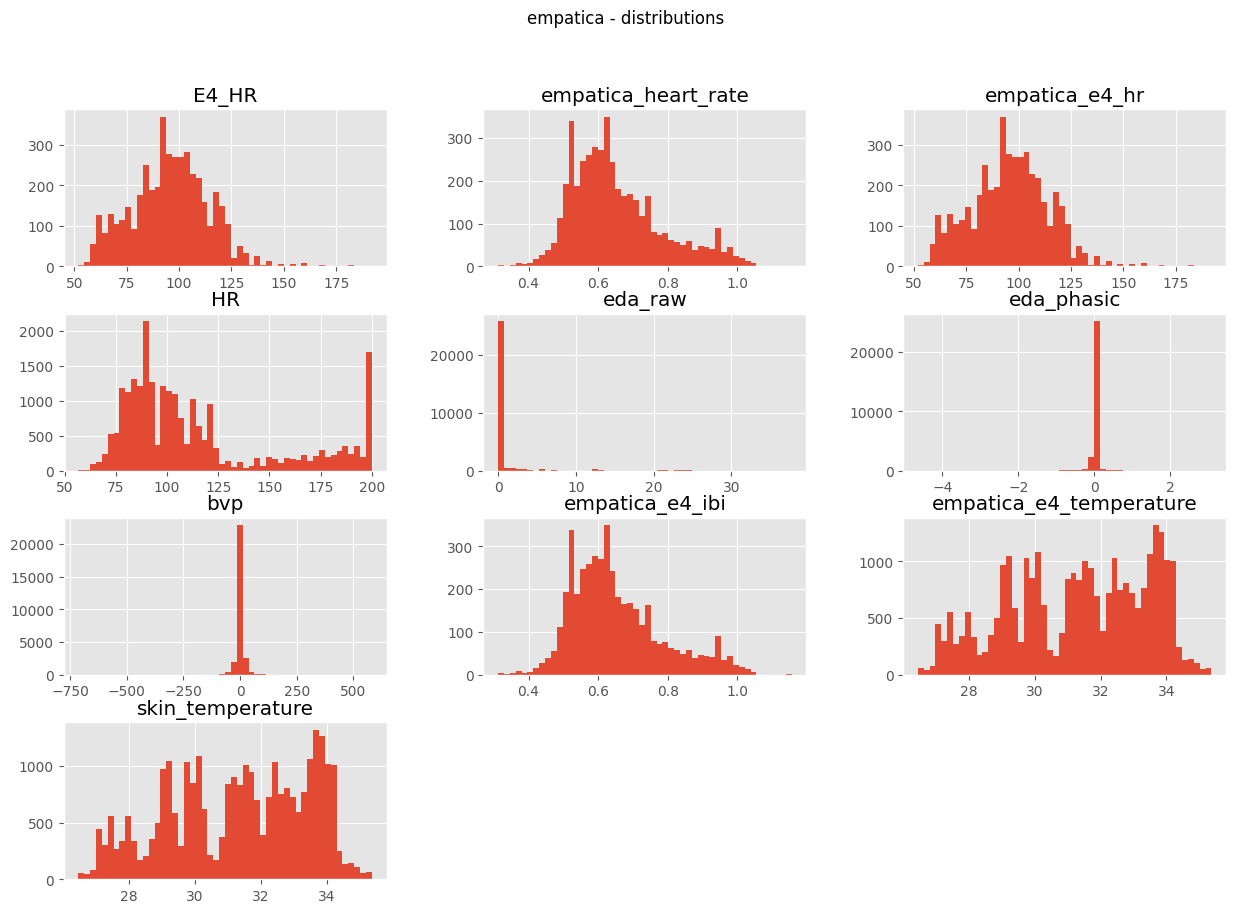

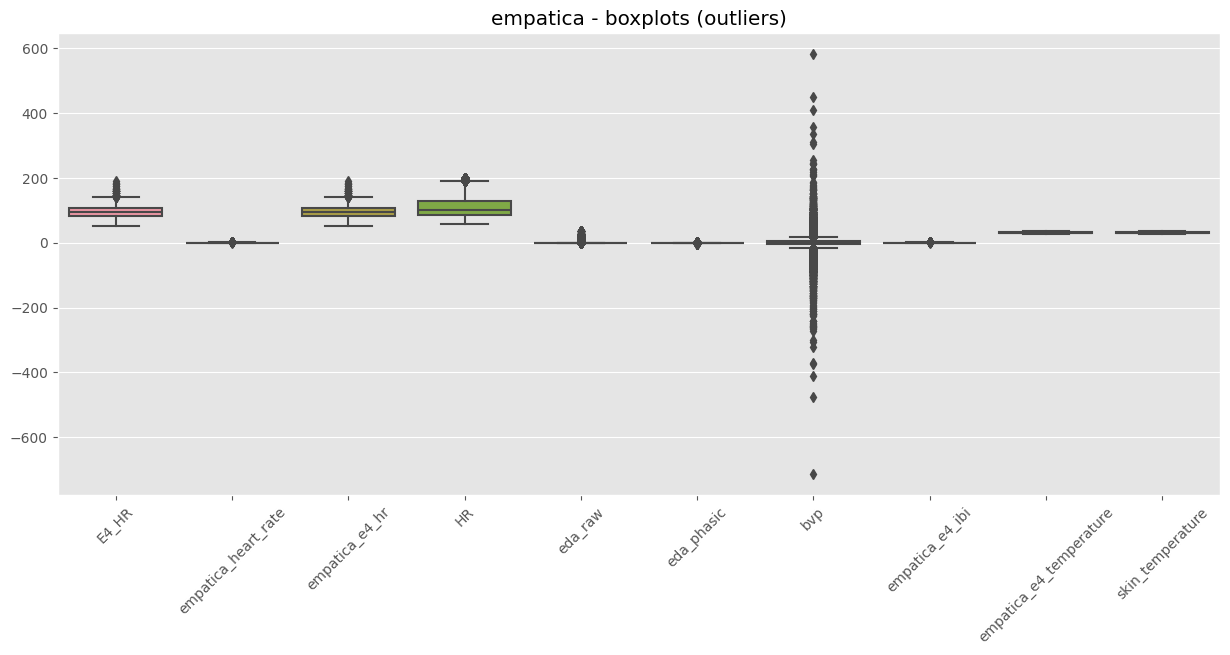

In [33]:
selected_group = "empatica"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

❌ E4_HR & IBI ~85% missing ❌</p>
</p>

E4_HR == empatica_e4_hr </p>
empatica_heart_rate == empatica_e4_ibi ?</p>
empatica_e4_temperature == skin_temperature</p>

and _HR_ is from ECG device & BVP with insane outliers

## ECG HR analysis


===== ECG_HR =====

--- Missing values ---
ECG_HR_smooth    0.026115
ECG_HR           0.025424
dtype: float64

--- Describe ---
             ECG_HR  ECG_HR_smooth
count  32430.000000   32407.000000
mean      96.177996      96.487886
std       16.990437      14.631366
min       40.080375      53.735858
25%       83.686086      85.911586
50%       95.692559      96.484894
75%      108.106550     107.410324
max      150.000000     142.079611


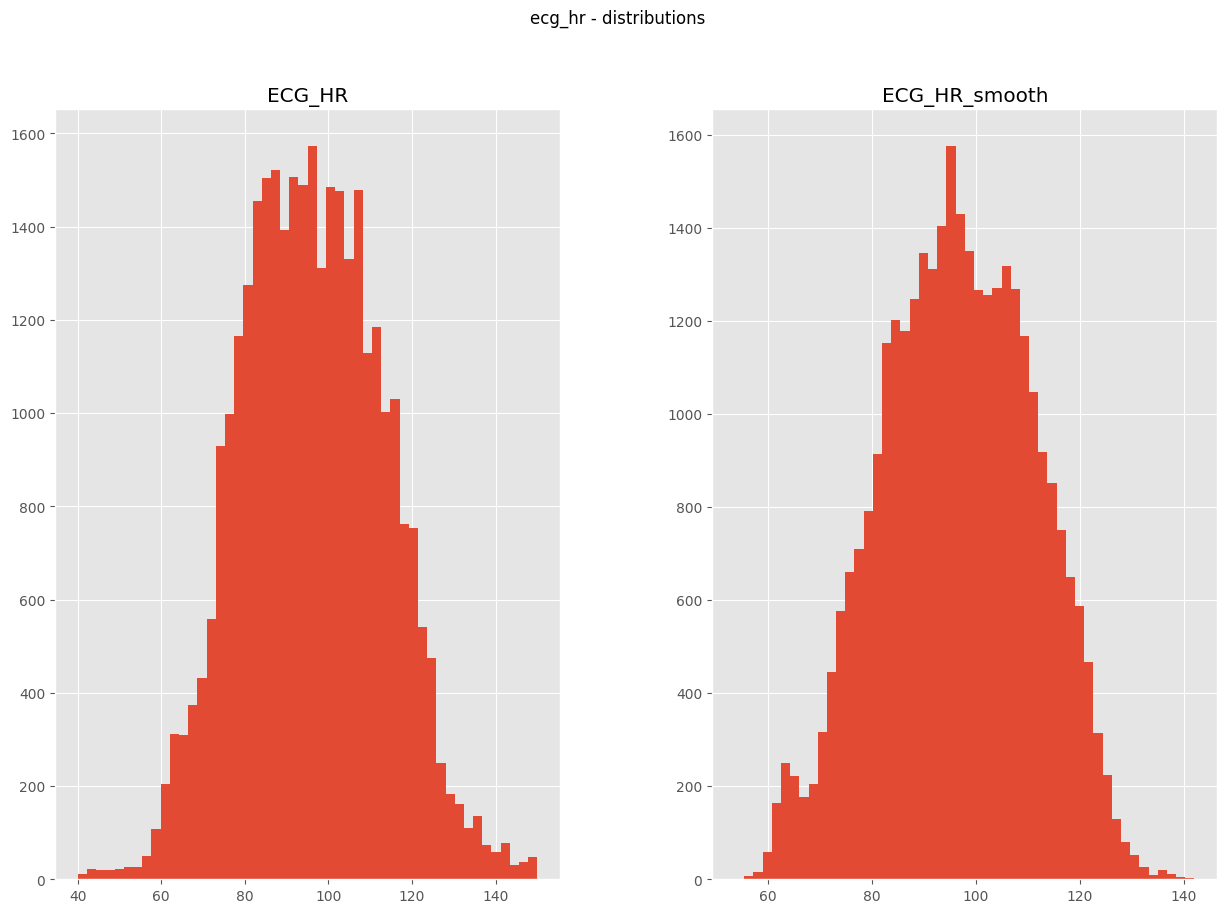

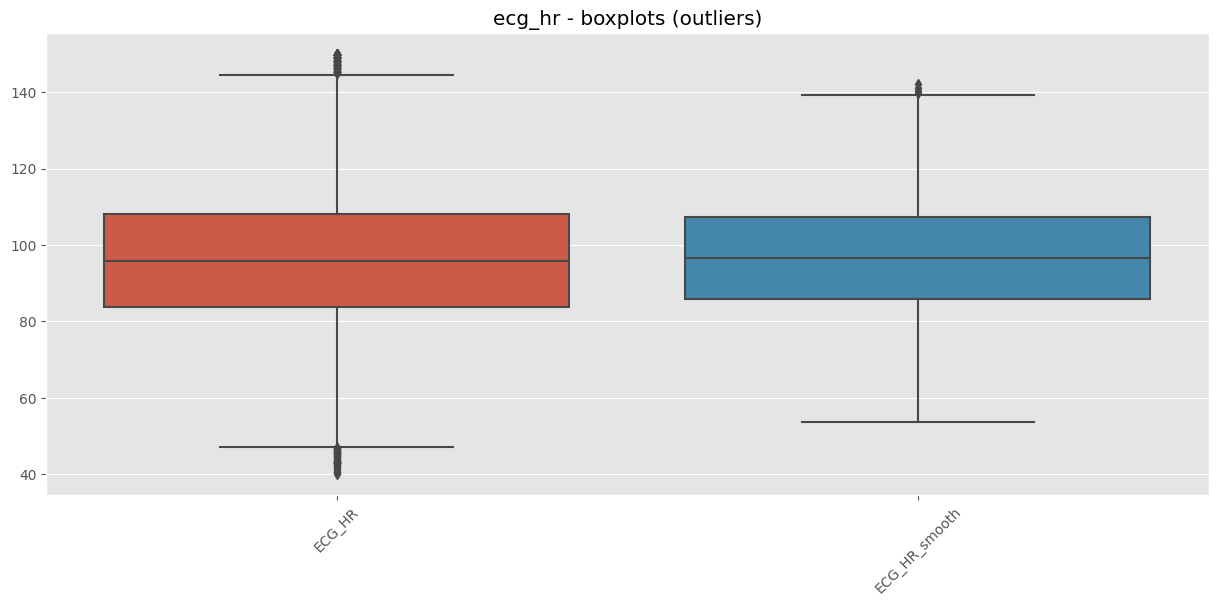

In [34]:
selected_group = "ecg_hr"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

## EEG analysis


===== EEG =====

--- Missing values ---
delta                      0.151549
theta                      0.151549
alpha                      0.151549
beta                       0.151549
gamma                      0.151549
frontal alpha              0.151549
frontal midline theta      0.151549
theta-beta ratio           0.151549
frontal alpha asymmetry    0.151549
frontal theta              0.151549
dtype: float64

--- Describe ---
              delta         theta         alpha          beta         gamma  \
count  2.153200e+04  2.153200e+04  2.153200e+04  2.153200e+04  2.153200e+04   
mean   2.878026e+00  7.351576e+00  5.256577e+00  9.162868e-01  3.313031e-01   
std    1.924376e+01  2.735606e+01  1.286921e+01  2.173714e+00  6.849817e-01   
min    5.221810e-09  1.216724e-11  5.992815e-13  7.583917e-15  1.914375e-16   
25%    1.254496e-01  1.627082e+00  1.255830e+00  3.151216e-01  1.240345e-01   
50%    3.675621e-01  2.932716e+00  2.757534e+00  4.914378e-01  2.078818e-01   
75%    9.8944

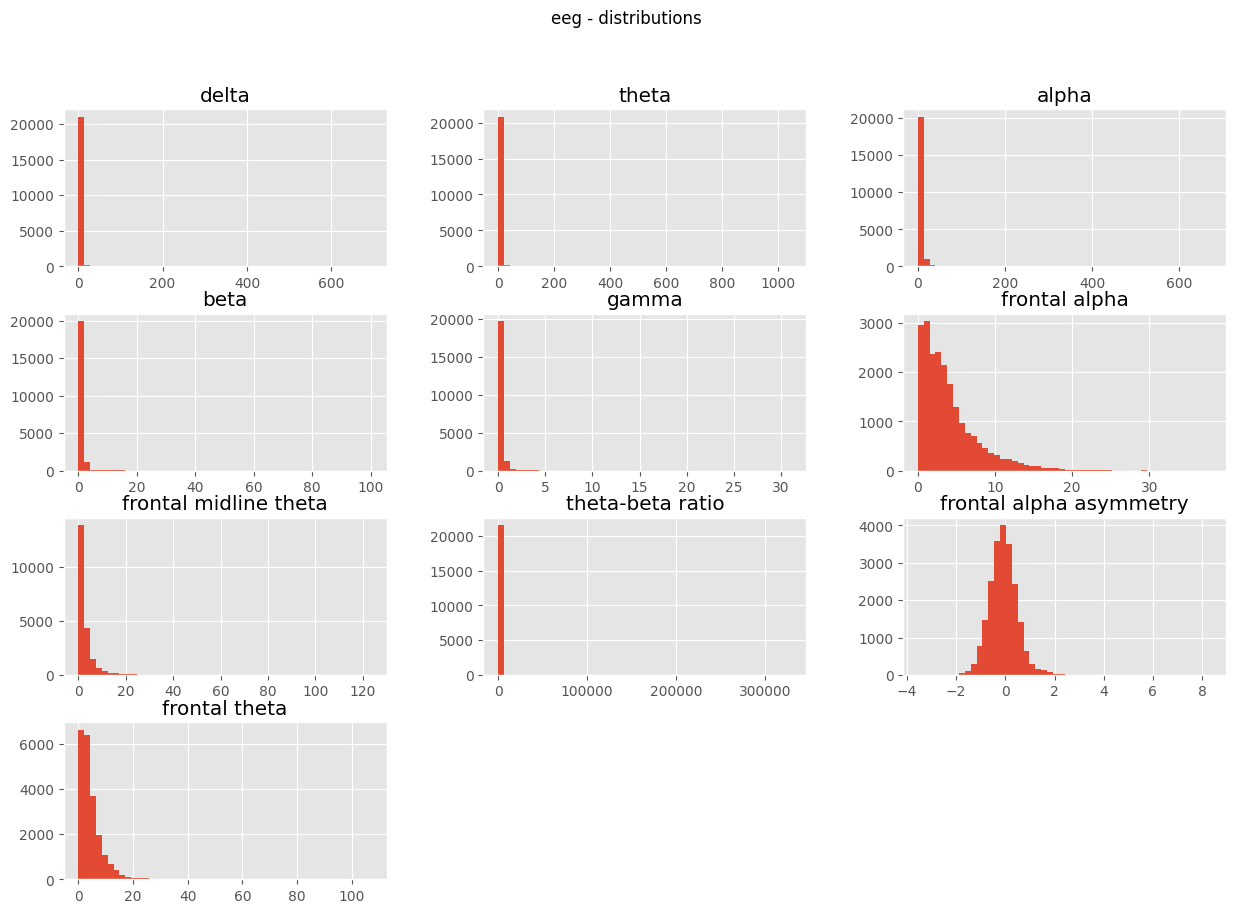

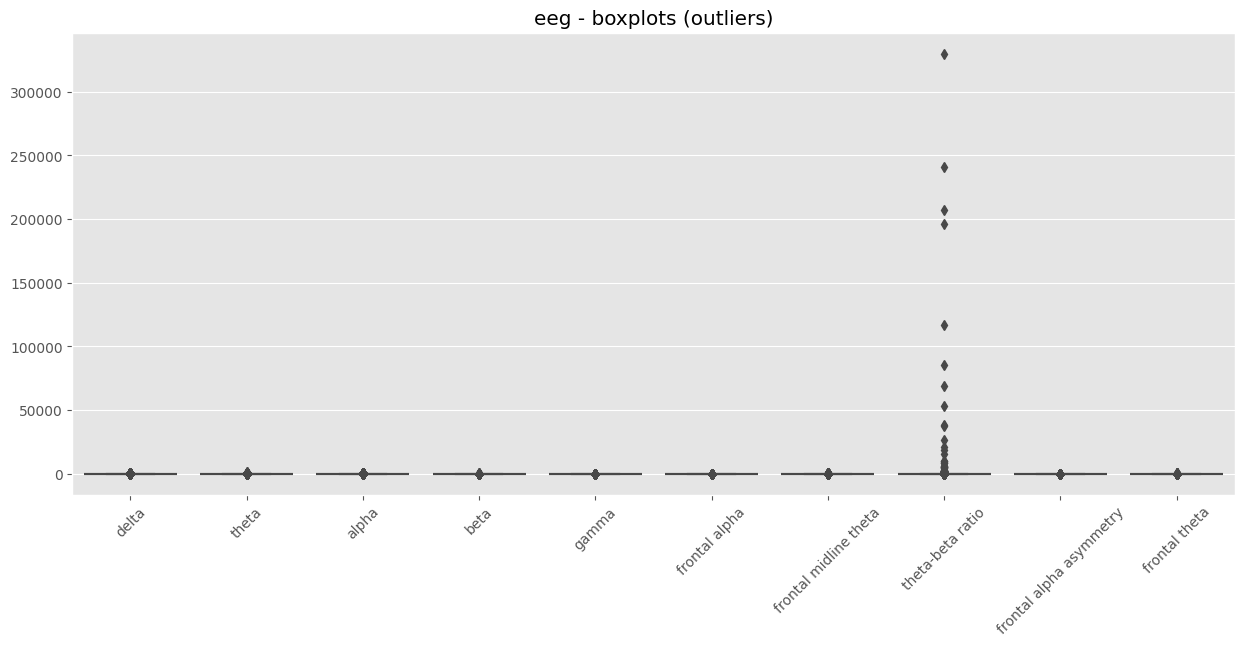

In [35]:
selected_group = "eeg"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

Missing values all around 15%

## Gaze analysis


===== GAZE =====

--- Missing values ---
GazeX    0.061696
GazeY    0.061696
dtype: float64

--- Describe ---
              GazeX         GazeY
count  31223.000000  31223.000000
mean     446.627746    494.281113
std      174.745662    157.920116
min     -171.155560     54.368748
25%      354.160410    384.520650
50%      446.430800    470.497700
75%      543.192995    578.686470
max     1166.226600   1114.157200


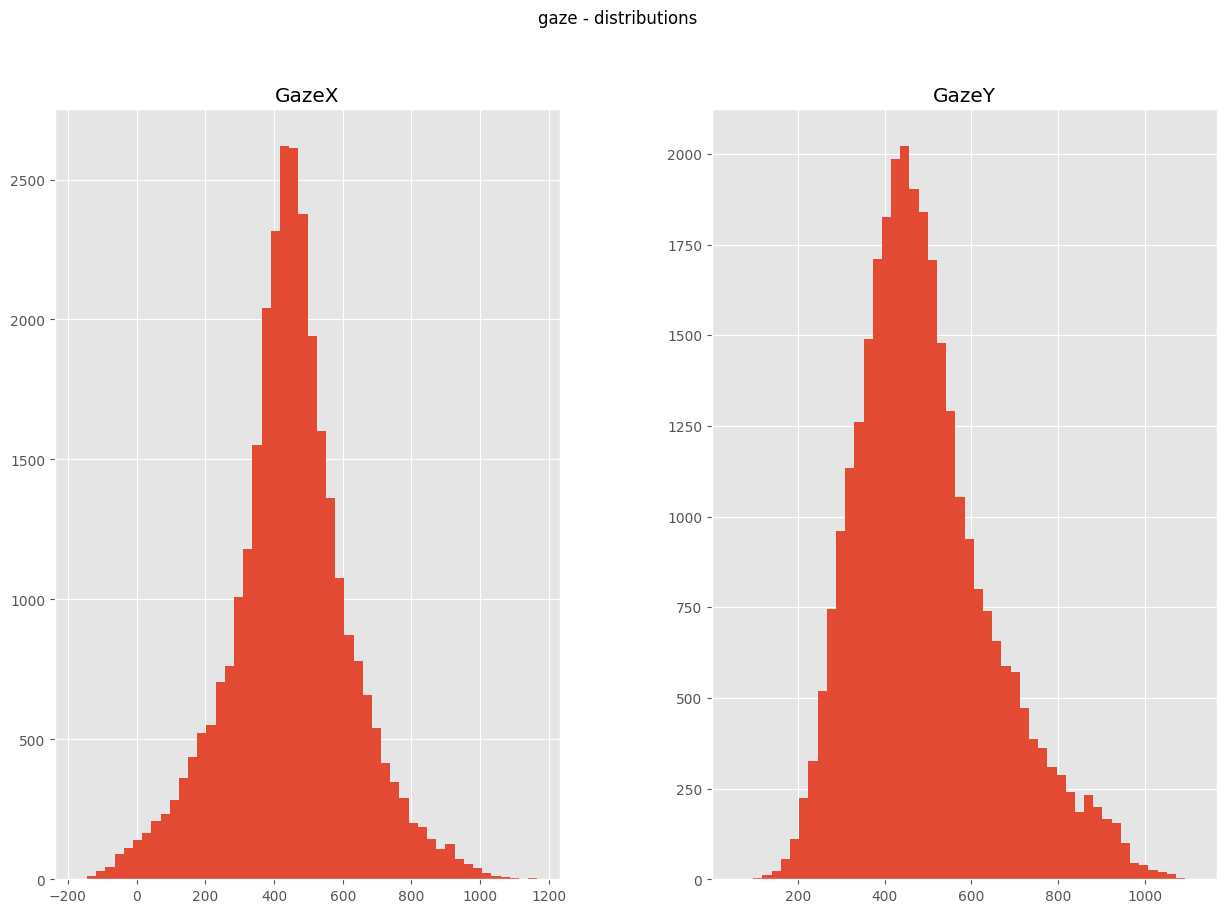

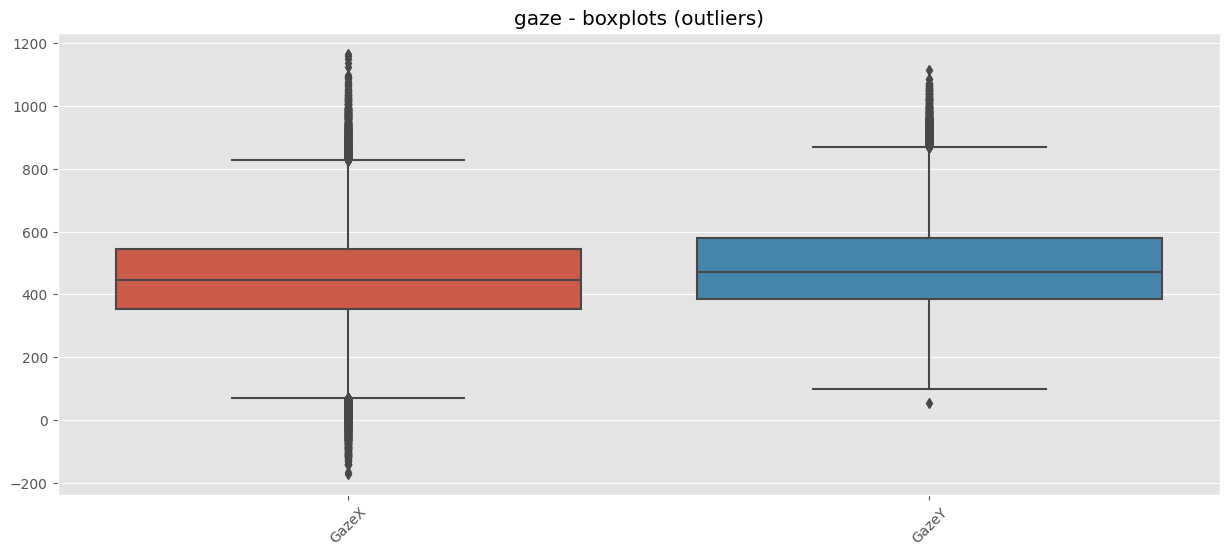

In [36]:
selected_group = "gaze"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

Low missingness (~6%) but min of _GazeX_ is negative! Have to limit to 0+

## GPS analysis


===== GPS =====

--- Missing values ---
latitude_corrected     0.355151
longitude_corrected    0.355151
cum_dist               0.355151
original_longitude     0.000240
original_latitude      0.000240
dtype: float64

--- Describe ---
       original_longitude  original_latitude  latitude_corrected  \
count        33268.000000       33268.000000        21458.000000   
mean            12.573019          55.706205           55.706381   
std              0.020420           0.015341            0.017622   
min             12.537699          55.681719           55.681724   
25%             12.564467          55.698659           55.683746   
50%             12.573764          55.706364           55.706529   
75%             12.590809          55.708043           55.728138   
max             12.598902          55.730717           55.730722   

       longitude_corrected      cum_dist  
count         21458.000000  21458.000000  
mean             12.577264    518.324462  
std               0.0155

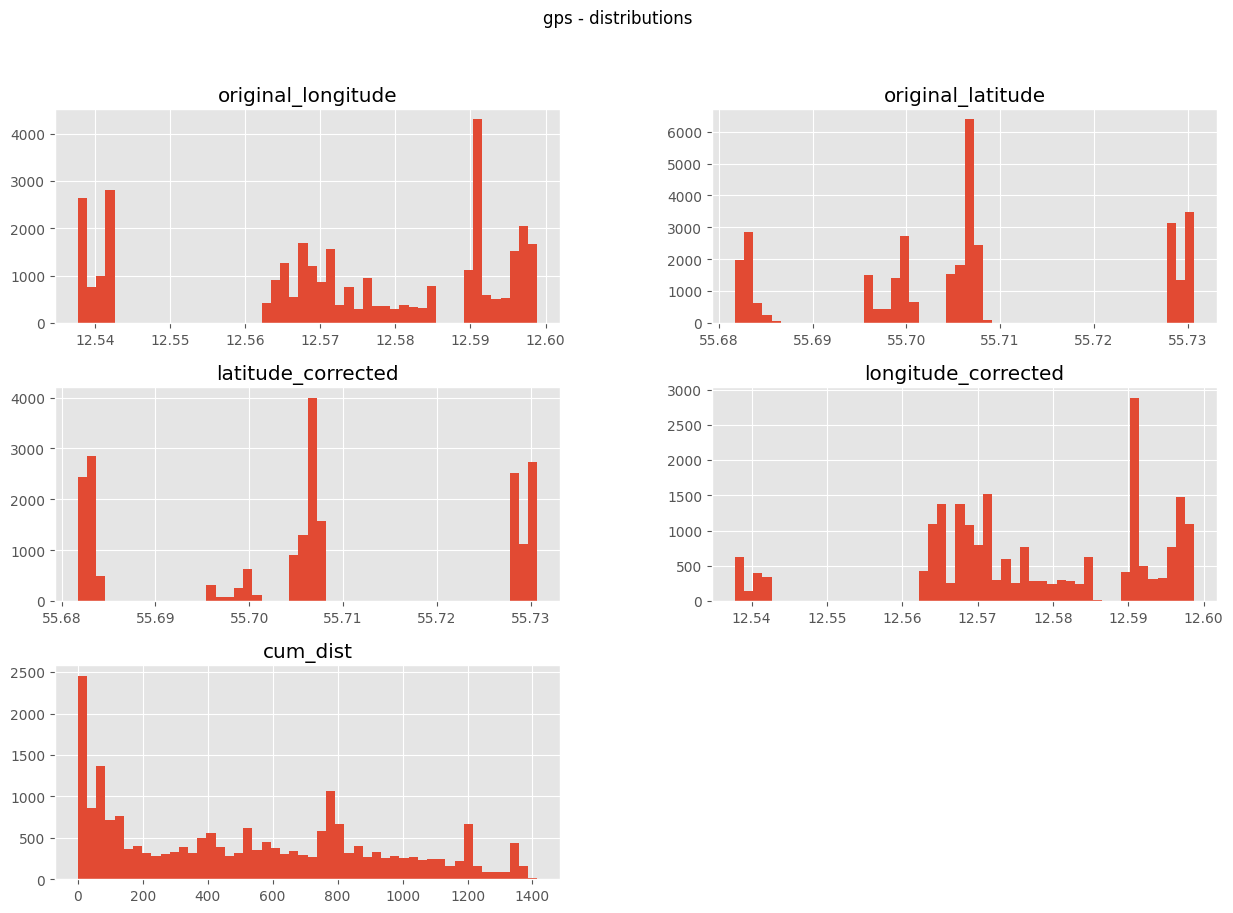

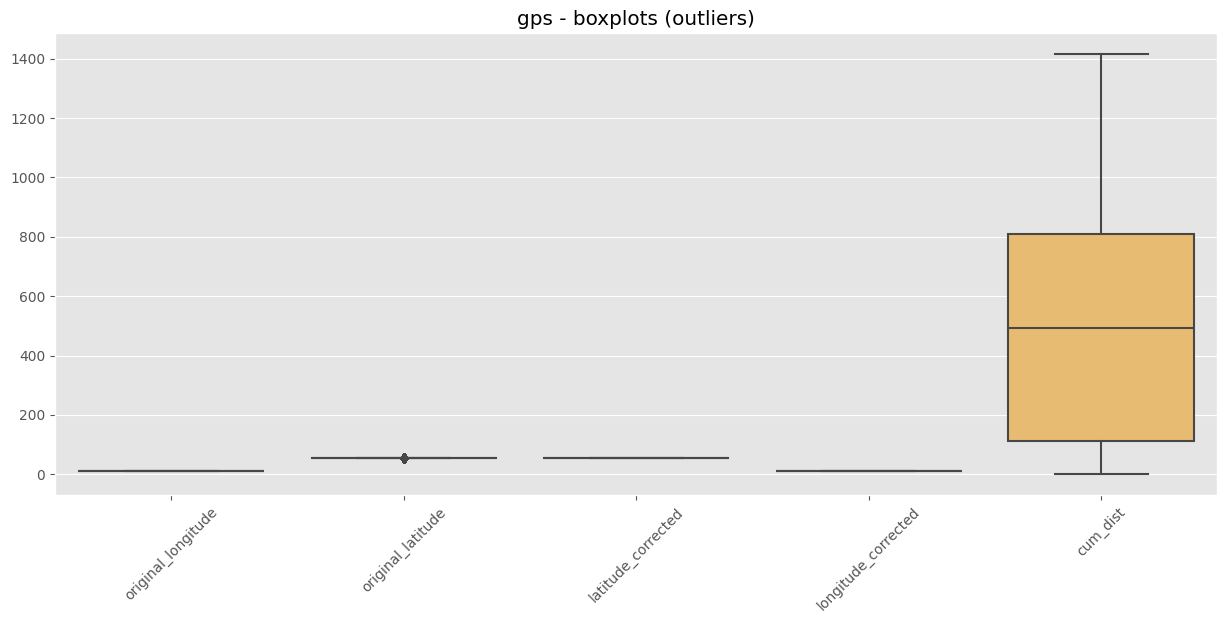

In [37]:
selected_group = "gps"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

latitude_corrected, longitude_corrected & cum_dist 35% missing ❌

## Noise analysis


===== NOISE =====

--- Missing values ---
noise_level             0.001412
sound_pressure_level    0.001412
dtype: float64

--- Describe ---
        noise_level  sound_pressure_level
count  33229.000000          33229.000000
mean      66.758501            667.585013
std        5.562633             55.626334
min       47.494000            474.940000
25%       62.913000            629.130000
50%       66.257576            662.575758
75%       70.324000            703.240000
max      110.093939           1100.939394


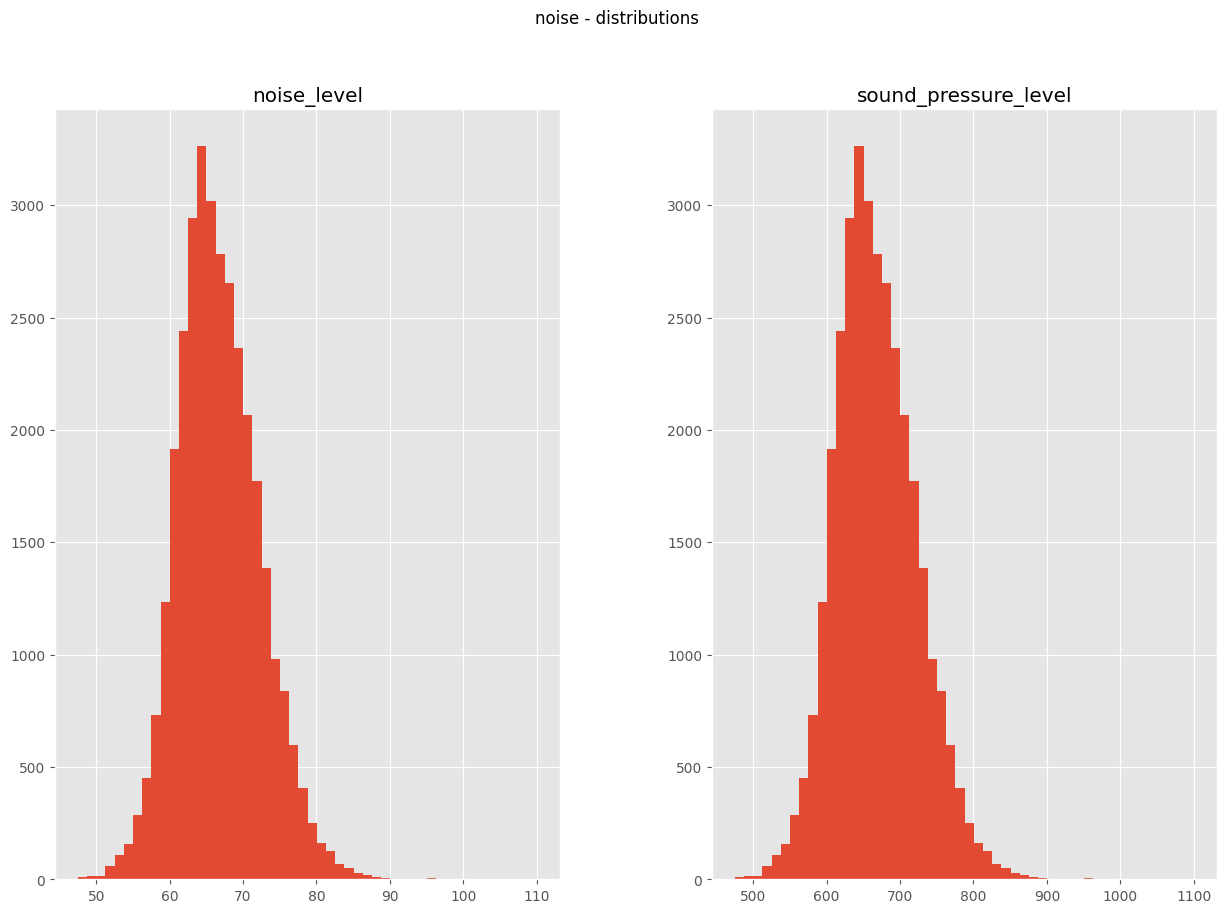

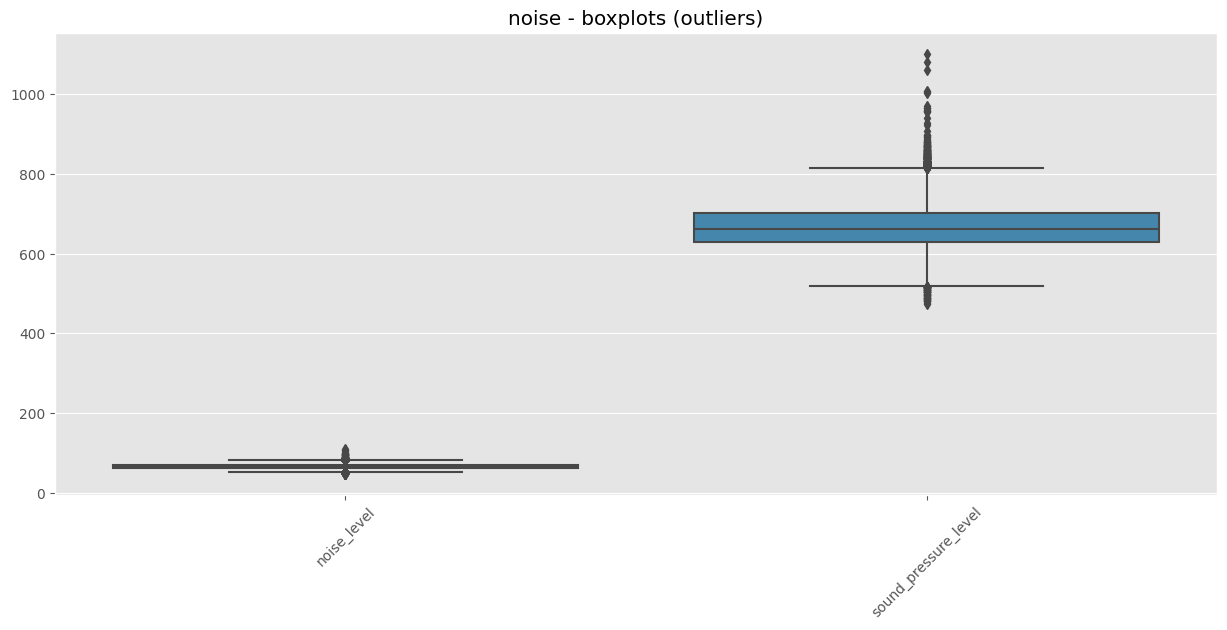

In [38]:
selected_group = "noise"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

Almost no missing data yay </p>
sound_pressure_level = noise_level * 10 ???

## Climate analysis


===== CLIMATE =====

--- Missing values ---
atmospheric_temperature    0.007904
wind_speed                 0.007904
mrt                        0.007904
air_temperature            0.001953
humidity                   0.001412
pm1_0                      0.001412
pm2_5                      0.001412
pm10_0                     0.001412
dtype: float64

--- Describe ---
       atmospheric_temperature      humidity    wind_speed           mrt  \
count             33013.000000  33229.000000  33013.000000  33013.000000   
mean                 22.980712     67.152157      1.492068     30.137804   
std                   2.812292     12.869878      0.940701      6.558642   
min                  17.900000     47.190000      0.005000     18.000000   
25%                  21.200001     57.865600      0.784474     23.900000   
50%                  22.299999     63.867200      1.330883     29.800000   
75%                  24.000000     74.846800      2.024846     35.900000   
max                  31.40

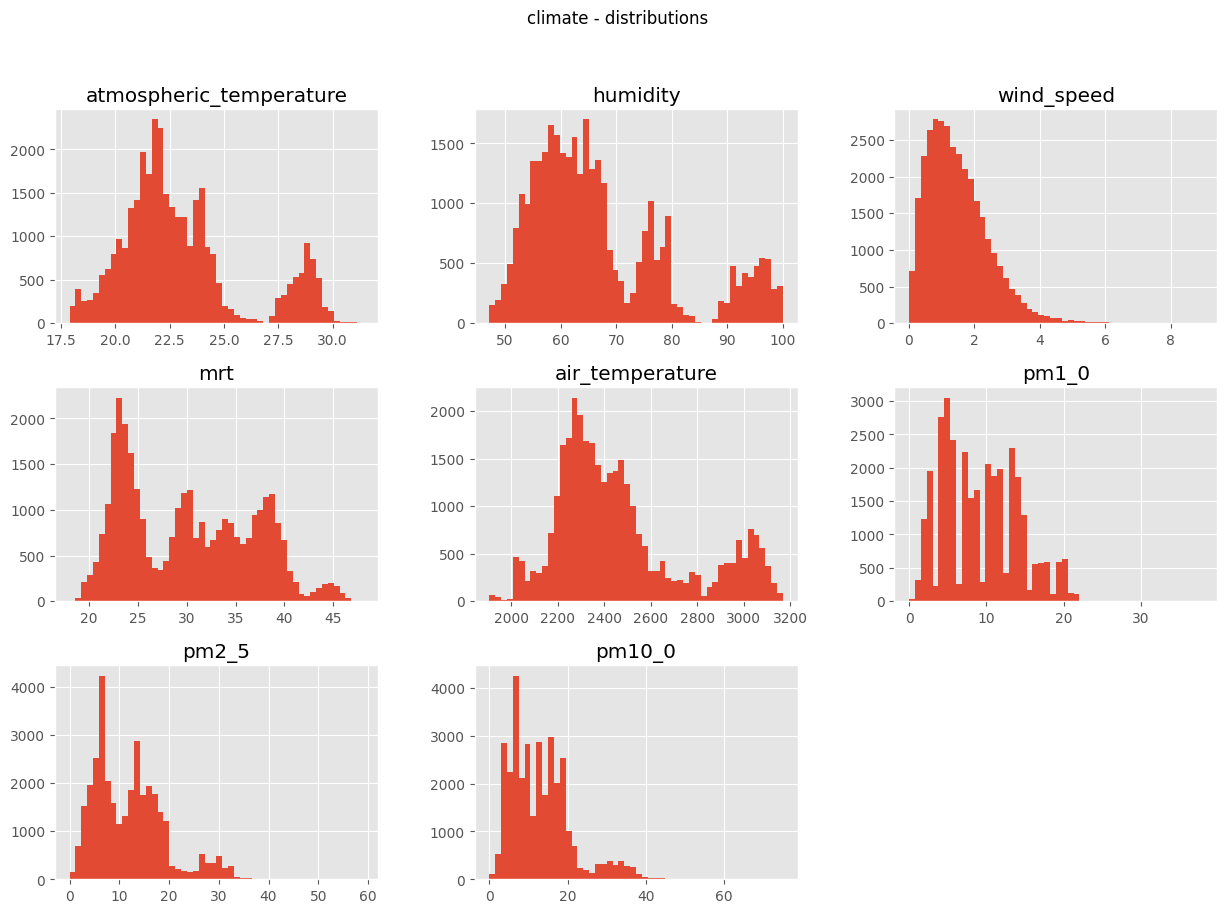

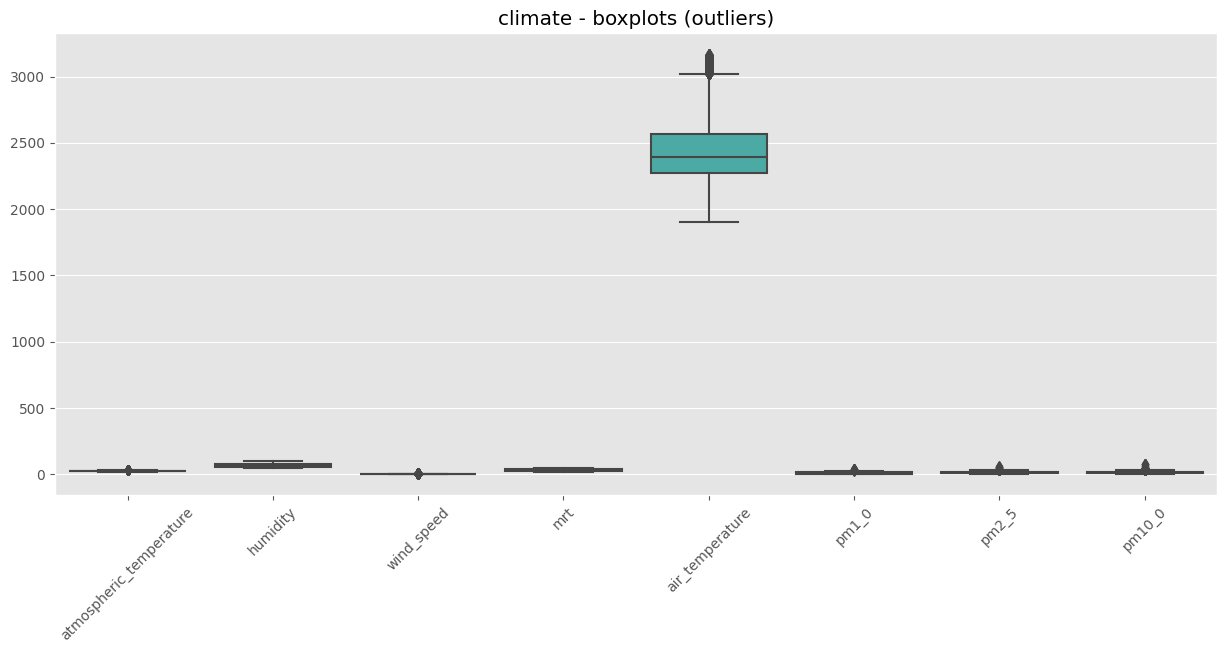

In [39]:
selected_group = "climate"  # change this

variables = group_variables[selected_group]
valid_df = valid_groups[selected_group]

group_df = collect_group_data(valid_df, variables, base_dir)

if group_df is not None:
    analyze_group(group_df, selected_group)

air_temperature = temperature * 100

___________

# Variable Summary

Participants variables were grouped into the following groups with the corresponding features:
- Empatica: "E4_HR", "empatica_heart_rate", "empatica_e4_hr", "HR","eda_raw", "eda_phasic","bvp", "empatica_e4_ibi","empatica_e4_temperature","skin_temperature"
- ECG: "ECG_HR", "ECG_HR_smooth"
- EEG: "delta","theta","alpha","beta","gamma","frontal alpha","frontal midline theta","theta-beta ratio","frontal alpha asymmetry","frontal theta"
- Gaze: "GazeX", "GazeY"
- GPS: "original_longitude", "original_latitude", "latitude_corrected", "longitude_corrected", "cum_dist"
- Climate: "atmospheric_temperature", "humidity", "wind_speed", "mrt", "air_temperature", "air_humidity", "air_pressure", "humidity_sensor"
            "pm1_0", "pm2_5", "pm10_0"
- Noise: "noise_level", "sound_pressure_level"

---

### Empatica insights

E4_HR, empatica_heart_rate, empatica_e4_hr and empatica_e4_ibi have all ~85% of misisng data so they will be not used and therefore deleted in the final version. HR variable has less than 20% of misisng data, however new added HR parameter from ECG device is even better so it will also not be used and deleted in the end.

empatica_e4_temperature, skin_temperature, eda_raw, eda_phasic, bvp are of great quality. empatica_e4_temperature seems better than skin_temperature therefore only one will stay for the data final version.

---

### ECG HR insights

Great quality has to stay.

---

### EEG insights

All variables from EEG have around 15% missing data, other than that all good.

---

### Gaze insights

Very low missing data (6%)! However GazeX has negative values which need to be deleted for the final version.

---

### Gaze insights

latitude_corrected, longitude_corrected & cum_dist 35% missing data.

---

### Noise insights

Pretty much no missing data :D </p>
Note that sound_pressure_level = noise_level * 10

---

### Climate insights

Very low missing data (<1%) and all looking good </p>
air_temperature = temperature * 100

__________
___________

# Path level

In [47]:
base_dir = os.path.join(rawdata, "fulldata_mine")

all_dfs = []

# -----------------------------
# LOAD ALL GOOD PARTICIPANTS
# -----------------------------
for sub in good_participants:

    sub_path = os.path.join(base_dir, sub)

    for ses in os.listdir(sub_path):

        file_path = os.path.join(
            sub_path,
            ses,
            "alldata.csv"
        )

        if not os.path.exists(file_path):
            continue

        try:
            df = pd.read_csv(file_path)

            if df.empty:
                continue

            df["participant_id"] = sub
            df["session_id"] = ses

            all_dfs.append(df)

            #print(f"Loaded {sub} / {ses}")

        except Exception as e:
            print(f"Error {sub} / {ses}: {e}")


# -----------------------------
# COMBINE
# -----------------------------
df = pd.concat(all_dfs, ignore_index=True)


# -----------------------------
# 1. PARTICIPANTS PER PATH
# -----------------------------
print("\nParticipants per path")
print(
    df.groupby("session_id")["participant_id"]
      .nunique()
)


# -----------------------------
# 2. PATH COVERAGE
# -----------------------------
print("\nPath coverage")
print(
    df.groupby("session_id")["cum_dist"]
      .agg(["min","max","mean","std"])
)


# -----------------------------
# 3. MISSINGNESS BY PATH
# -----------------------------
vars_check = [
    "ECG_HR",
    "GazeX",
    "GazeY",
    "noise_level",
    "atmospheric_temperature", "air_temperature",
    "delta","theta","alpha","beta","gamma","frontal alpha",
    "humidity", "wind_speed"
]

print("\nMissingness by path (%)")
print(
    df.groupby("session_id")[vars_check]
      .apply(lambda x: x.isna().mean()*100)
)


# -----------------------------
# 4. PATH SEGMENTS (100m bins)
# -----------------------------
df["path_bin"] = (df["cum_dist"] // 100) * 100

path_summary = (
    df.groupby(
        ["session_id","path_bin"]
    )[[
        "ECG_HR",
        "noise_level"
    ]]
    .mean()
)

print("\nPath hotspots")
print(path_summary)

# variation across participants at same location (between-participant variation)
print("\nVariability across participants within each path bin")

path_var = (
    df.groupby(["session_id","path_bin"])["ECG_HR"]
      .agg(["mean","std"])
)

print(path_var)


Participants per path
session_id
ses-Hellerup     5
ses-Nordhavn     8
ses-Norrebro     5
ses-Norreport    4
Name: participant_id, dtype: int64

Path coverage
                min     max        mean         std
session_id                                         
ses-Hellerup   18.6  1414.9  605.544929  449.279257
ses-Nordhavn    0.0  1224.2  536.909701  414.855100
ses-Norrebro    0.0   922.2  335.830329  312.723362
ses-Norreport   0.0  1091.6  445.229870  333.910984

Missingness by path (%)
                 ECG_HR      GazeX      GazeY  noise_level  \
session_id                                                   
ses-Hellerup   4.528917  12.118931  12.118931     0.276001   
ses-Nordhavn   2.107062   8.436381   8.436381     0.024406   
ses-Norrebro   2.006087   0.000000   0.000000     0.041505   
ses-Norreport  1.400173   0.864304   0.864304     0.328436   

               atmospheric_temperature  air_temperature      delta      theta  \
session_id                                       

# Path Summary

### Participant coverage per path

→ Uneven </p>

Nordhavn   = 8 participants </p>
Hellerup   = 5 </p>
Norrebro   = 5 </p>
Norreport  = 4 </p>

- Nordhavn has more statistical weight </p>
- Norreport has the weakest support

-------------

### Path distance (cum_dist)

The different paths have different distances: </p>

Hellerup   ~1415 m </p>
Nordhavn   ~1224 m </p>
Norreport  ~1092 m </p>
Norrebro   ~922 m </p>

So when further analysed they might be compared: </p>
- by normalized distance (% route completed), OR </p>
- by path bins (which is what I have here) </p>

------------

### ECG HR across paths </p>

Missingness around 1–4.5%, therefore ECG_HR is stable at path-level! </p>

------------

### Gaze

Different missings across paths: </p>
- Norrebro:   0% </p>
- Norreport:  1% </p>
- Hellerup: 12% </p>
- Nordhavn:  8% </p>

route-specific occlusion problems? </p>
path-specific recording issues? </p>
different participant behavior? </p>

-------------------

### EEG

Was some significant amount of data misisng (differently) per path.

- Norrebro:   ~16% </p>
- Norreport:  ~40% </p>
- Hellerup: ~32% </p>
- Nordhavn:  ~46% </p>

→ EEG quality may be path-dependent?

-------------------------

### Climate + Noise

Both great quality, less than 1% missing

----------------

### Path hotspots

ECG_HR shows repeated increases along paths
➜ possible spatially structured physiological responses

Examples:

* Hellerup: HR rises ~93 → 106 bpm around 700–1200m

* Nordhavn: HR peaks ~107 bpm around 900m

* Norrebro: HR peaks ~105 bpm around 500–900m

* Norreport: HR increases ~85 → 102 bpm toward later path segments

➜ some route segments may repeatedly trigger elevated responses?

---

### Between-participant variability within paths

Participant consistency differs by path

* Hellerup / Nordhavn: Higher variability (std ~16–19 bpm)
  ➜ more heterogeneous responses across participants

* Norrebro: Low HR variability (std ~4–8 bpm)
  ➜ more consistent responses across participants

* Norreport: Moderate variability (std ~13–15 bpm)

Possible interpretation:
* some paths induce shared responses
* others may be more participant-dependent